In [6]:
import geopandas as gpd
from shapely.geometry import Point, Polygon
import pandas as pd
import numpy as np
from utils.landuse import LandUseMap
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

In [3]:
fresno_landuse = LandUseMap()
fresno_landuse.loadmap("Fresno")

In [7]:
# bounding box of the landuse map
fresno_landuse.gdf.total_bounds

array([-119.93429933,   36.66268537, -119.65052725,   36.91098697])

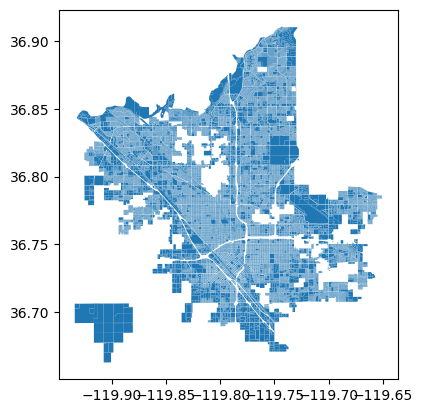

In [8]:
fresno_landuse.gdf.plot()
plt.show()

In [10]:
# Query a point
print(fresno_landuse((-119.80, 36.7)))

Public and Institutional


In [14]:
# Query a rectangle
print(np.unique(fresno_landuse((-119.80, 36.7, -119.78, 36.72))))

['Commercial Community' 'Commercial Regional' 'Corridor/Center Mixed Use'
 'Heavy Industrial' 'Light Industrial' 'Neighborhood Mixed Use' 'No Value'
 'Office' 'Open Space' 'Park and Recreation' 'Public and Institutional'
 'Residential Multi-Family, Medium High Density'
 'Residential Single-Family, Medium Density']


In [3]:
print(fresno_landuse((-119.80, 36.7, -119.78, 36.72)))

['Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Residential Single-Family, Medium Density', 'Resident

/Users/shangjiedu/anaconda3/envs/env_ai/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [17]:
fresno_landuse.gdf["ZoningDescription"].unique()

array(['Office', 'Light Industrial',
       'Residential Single-Family, Medium Density',
       'Residential Multi-Family, Medium High Density',
       'Commercial Community', 'Corridor/Center Mixed Use',
       'Commercial Regional', 'Public and Institutional',
       'Commercial General', 'Mobile Home Park', 'Park and Recreation',
       'Open Space', 'Residential Single-Family, Medium Low Density',
       'Residential Multi-Family, High Density', 'No Value',
       'Heavy Industrial', 'Residential Single-Family, Low Density',
       'Business Park', 'Residential Multi-Family, Urban Neighborhood',
       'Residential Single-Family, Extremely Low Density',
       'Residential Estate',
       'Residential Single-Family, Very Low Density',
       'Commercial Highway and Auto', 'Neighborhood Mixed Use',
       'Regional Mixed Use', 'Commercial Main Street',
       'Commercial Recreation', 'Downtown Neighborhood', 'Downtown Core',
       'Downtown General'], dtype=object)

# geojson

In [2]:
file_path = "./landuse_data/Zoning.geojson"

gdf = gpd.read_file(file_path)

print(gdf.head())

   ObjectID       APN Zoning ZoningDescription ZoningString Split  \
0         1  30302145      O            Office     O/UGM/cz  None   
1         2  30302154      O            Office     O/UGM/cz  None   
2         3  30302155      O            Office     O/UGM/cz  None   
3         4  30302156      O            Office     O/UGM/cz  None   
4         5  30302157      O            Office     O/UGM/cz  None   

  RezoneApplicationNo Date_Adopted Date_Approved Effective_Date OrdinanceNo  \
0                None          NaT           NaT            NaT        None   
1                None          NaT           NaT            NaT        None   
2                None          NaT           NaT            NaT        None   
3                None          NaT           NaT            NaT        None   
4                None          NaT           NaT            NaT        None   

  ZoneChanges     Acres  CouncilDistrict    District    CouncilPerson  \
0        None  0.966890              

In [11]:
longitude = -119.8
latitude = 36.77

# Create a GeoDataFrame for the given point
point = gpd.GeoDataFrame([{'geometry': Point(longitude, latitude)}], crs=gdf.crs)

# If the original gdf has a different crs, you would convert the point's crs like so:
# point = point.to_crs(gdf.crs)

# Spatial join to find which polygon the point falls within
# It's 'inner' by default, which means it will only return matching rows
point_in_gdf = gpd.sjoin(point, gdf, how="inner", op='intersects')

# Now, 'point_in_gdf' contains the matching rows from 'gdf' with the additional information of the point
# Get the 'ZoningDescription' from the joined GeoDataFrame
zoning_description = point_in_gdf.iloc[0]['ZoningDescription'] if not point_in_gdf.empty else None

print(f"The ZoningDescription for location ({latitude}, {longitude}) is: {zoning_description}")

The ZoningDescription for location (36.77, -119.8) is: Residential Single-Family, Medium Density


/Users/shangjiedu/anaconda3/envs/env_ai/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3448: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [9]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [10]:
point.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

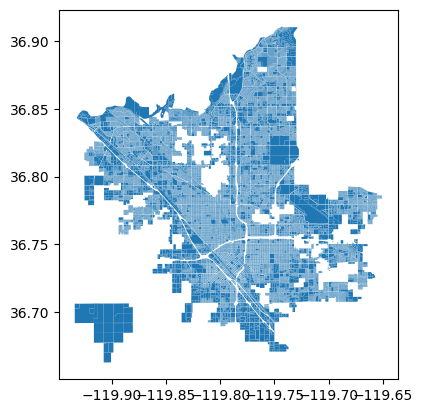

In [4]:
gdf.plot()